# Notebook 1: Probabilistic Linear Regression with Pyro

**Block 1 — Introduction to Probabilistic Machine Learning**

In this notebook we will:

1. Get familiar with **Pyro distributions** — the basic building blocks.
2. Learn how to define **probabilistic models** in Pyro.
3. Perform **maximum likelihood inference** using Pyro's SVI.
4. Make **predictions with uncertainty** from a probabilistic linear regression model.

We go step by step. If you already know PyTorch, the transition to Pyro is smooth.

---
## 0. Setup

In [1]:
# Run this cell in Google Colab to install Pyro
# (skip if already installed)
!pip install -q pyro-ppl graphviz

You should consider upgrading via the '/Users/zp25hk/Library/CloudStorage/GoogleDrive-andresrmasegosa@gmail.com/My Drive/teaching/2026-Spring/2026-PhD-PML-Claude/.venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np

# For reproducibility
pyro.set_rng_seed(42)
torch.manual_seed(42)

# Clear Pyro's parameter store (important when re-running cells)
pyro.clear_param_store()

# Plot style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

# Path to save figures (for use in slides)
FIGURES_DIR = 'figures/'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'PyTorch version: {torch.__version__}')
print(f'Pyro version: {pyro.__version__}')

PyTorch version: 2.8.0
Pyro version: 1.9.1


---
## 1. Pyro Distributions

Distributions are the **fundamental building blocks** of probabilistic models. Pyro wraps PyTorch distributions and adds features needed for probabilistic programming.

> **Docs:** [`pyro.distributions`](https://docs.pyro.ai/en/stable/distributions.html) — full catalog of available distributions.
> Pyro distributions inherit from `torch.distributions.Distribution`, so any operation you know from PyTorch works here too.

Let's start with the most important distribution: the **Gaussian (Normal)**.

### 1.1 Creating a distribution

A Pyro distribution is a **Python object** that encodes a probability distribution. You instantiate it with its parameters — nothing is sampled yet at this point.

- [`dist.Normal(loc, scale)`](https://docs.pyro.ai/en/stable/distributions.html#normal) takes:
  - `loc` — the mean $\mu$
  - `scale` — the standard deviation $\sigma$ (not the variance!)
- The object exposes properties like `.mean`, `.stddev`, `.variance`, `.support`, etc.

In [3]:
# dist.Normal uses keyword arguments 'loc' (mean) and 'scale' (std dev).
# Note: 'scale' = standard deviation σ, NOT variance σ².
# Creating the object does NOT draw any samples — it just defines the distribution.
normal = dist.Normal(loc=0.0, scale=1.0)
print(f'Distribution: {normal}')
print(f'Mean: {normal.mean}')
print(f'Std:  {normal.stddev}')

Distribution: Normal(loc: 0.0, scale: 1.0)
Mean: 0.0
Std:  1.0


### 1.2 Sampling

[`.sample(sample_shape)`](https://docs.pyro.ai/en/stable/distributions.html#pyro.distributions.Distribution.sample) draws independent samples from the distribution and returns them as a `torch.Tensor`.

- `normal.sample()` → one scalar sample (shape `[]`)
- `normal.sample((N,))` → batch of N samples (shape `[N]`)

Samples are **not differentiable** by default. For reparameterization-based gradients (used in Bayesian inference), Pyro uses `.rsample()` internally.

In [4]:
# Draw a single sample
x = normal.sample()
print(f'One sample: {x.item():.4f}')

# Draw many samples
samples = normal.sample((1000,))
print(f'1000 samples: shape = {samples.shape}, mean = {samples.mean():.3f}, std = {samples.std():.3f}')

One sample: 0.3367
1000 samples: shape = torch.Size([1000]), mean = 0.016, std = 0.959


### 1.3 Log-probability

[`.log_prob(value)`](https://docs.pyro.ai/en/stable/distributions.html#pyro.distributions.Distribution.log_prob) evaluates $\log p(x)$ for a given value. We work in log-space because:

1. **Numerical stability:** probabilities of many observations multiplied together underflow to zero; log-probabilities are added instead.
2. **Optimization:** gradient-based optimizers work on sums, and $\log p(\mathcal{D}|\theta) = \sum_i \log p(x_i|\theta)$.

This is the foundation of **likelihood-based learning** — everything in this course flows from computing `log_prob`.

In [5]:
# log p(x=0) for a N(0,1)
log_p = normal.log_prob(torch.tensor(0.0))
print(f'log p(x=0.0) = {log_p.item():.4f}')
print(f'    p(x=0.0) = {torch.exp(log_p).item():.4f}')

# log p(x=3) — a value far from the mean has lower probability
log_p_far = normal.log_prob(torch.tensor(3.0))
print(f'\nlog p(x=3.0) = {log_p_far.item():.4f}')
print(f'    p(x=3.0) = {torch.exp(log_p_far).item():.4f}')

log p(x=0.0) = -0.9189
    p(x=0.0) = 0.3989

log p(x=3.0) = -5.4189
    p(x=3.0) = 0.0044


### 1.4 Visualizing a distribution

Let's visualize samples and the density of a Normal distribution.

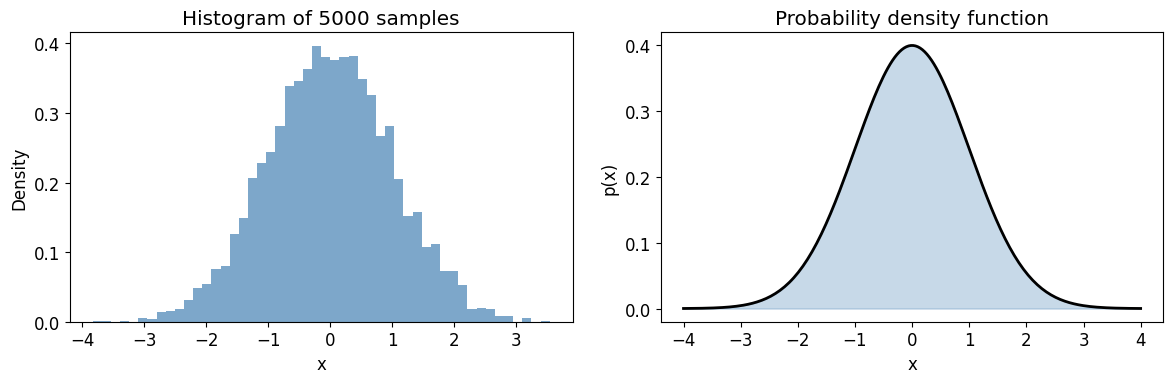

In [6]:
# Sample and plot
samples = dist.Normal(0.0, 1.0).sample((5000,))

x_grid = torch.linspace(-4, 4, 200)
log_probs = dist.Normal(0.0, 1.0).log_prob(x_grid)
density = torch.exp(log_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(samples.numpy(), bins=50, density=True, alpha=0.7, color='steelblue')
axes[0].set_title('Histogram of 5000 samples')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')

axes[1].plot(x_grid.numpy(), density.numpy(), 'k-', linewidth=2)
axes[1].fill_between(x_grid.numpy(), density.numpy(), alpha=0.3, color='steelblue')
axes[1].set_title('Probability density function')
axes[1].set_xlabel('x')
axes[1].set_ylabel('p(x)')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}normal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 Comparing distributions with different parameters

This is the key idea from the slides: **two distributions with the same mean but different variance** convey very different levels of confidence.

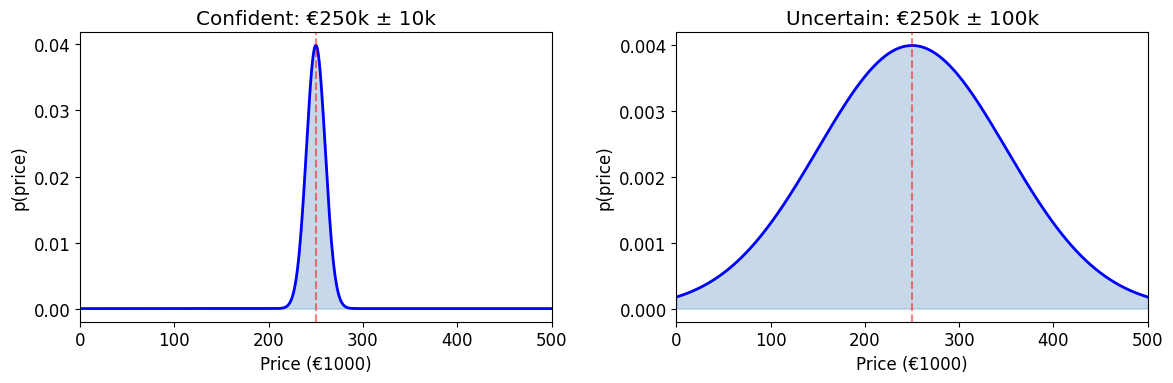

Same mean, very different decisions!


In [7]:
# Two Gaussians: same mean, different uncertainty
d_confident = dist.Normal(250.0, 10.0)   # confident prediction
d_uncertain = dist.Normal(250.0, 100.0)   # uncertain prediction

x_grid = torch.linspace(0, 500, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confident
density_conf = torch.exp(d_confident.log_prob(x_grid))
axes[0].plot(x_grid.numpy(), density_conf.numpy(), 'b-', linewidth=2)
axes[0].fill_between(x_grid.numpy(), density_conf.numpy(), alpha=0.3, color='steelblue')
axes[0].axvline(250, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Confident: \u20ac250k \u00b1 10k')
axes[0].set_xlabel('Price (\u20ac1000)')
axes[0].set_ylabel('p(price)')
axes[0].set_xlim(0, 500)

# Uncertain
density_unc = torch.exp(d_uncertain.log_prob(x_grid))
axes[1].plot(x_grid.numpy(), density_unc.numpy(), 'b-', linewidth=2)
axes[1].fill_between(x_grid.numpy(), density_unc.numpy(), alpha=0.3, color='steelblue')
axes[1].axvline(250, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Uncertain: \u20ac250k \u00b1 100k')
axes[1].set_xlabel('Price (\u20ac1000)')
axes[1].set_ylabel('p(price)')
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}two_gaussians_different_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Same mean, very different decisions!')

### 1.6 Other useful distributions

Pyro provides a rich library of distributions. The [full catalog](https://docs.pyro.ai/en/stable/distributions.html) includes continuous, discrete, and multivariate families.

The three we will use most in this course:

| Distribution | Pyro class | Use case |
|:-------------|:-----------|:---------|
| Normal | [`dist.Normal(loc, scale)`](https://docs.pyro.ai/en/stable/distributions.html#normal) | Regression (this notebook) |
| Bernoulli | [`dist.Bernoulli(probs)`](https://docs.pyro.ai/en/stable/distributions.html#bernoulli) | Binary classification (Block 2) |
| Categorical | [`dist.Categorical(probs)`](https://docs.pyro.ai/en/stable/distributions.html#categorical) | Multi-class / clustering (Block 3) |

In [8]:
# Bernoulli — for binary outcomes (Block 2: Classification)
bern = dist.Bernoulli(probs=0.7)
samples_bern = bern.sample((10,))
print(f'Bernoulli(0.7) samples: {samples_bern.tolist()}')
print(f'  log p(y=1) = {bern.log_prob(torch.tensor(1.0)).item():.4f}')
print(f'  log p(y=0) = {bern.log_prob(torch.tensor(0.0)).item():.4f}')

print()

# Categorical — for multi-class outcomes (Block 3: Clustering)
cat = dist.Categorical(probs=torch.tensor([0.2, 0.5, 0.3]))
samples_cat = cat.sample((10,))
print(f'Categorical([0.2, 0.5, 0.3]) samples: {samples_cat.tolist()}')

Bernoulli(0.7) samples: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0]
  log p(y=1) = -0.3567
  log p(y=0) = -1.2040

Categorical([0.2, 0.5, 0.3]) samples: [2, 2, 2, 1, 1, 0, 2, 1, 2, 2]


> **Summary so far:** Pyro distributions let us create probability distributions, draw samples, and compute log-probabilities. These three operations — **create**, **sample**, **log_prob** — are all we need to build probabilistic models.

---
## 2. Pyro Models

A **probabilistic model** in Pyro is a regular Python function decorated implicitly with two special primitives:

| Primitive | Signature | Role |
|:----------|:----------|:-----|
| [`pyro.sample`](https://docs.pyro.ai/en/stable/primitives.html#pyro.primitives.sample) | `pyro.sample(name, dist, obs=None)` | Declares a **random variable** — observed or latent |
| [`pyro.param`](https://docs.pyro.ai/en/stable/primitives.html#pyro.primitives.param) | `pyro.param(name, init, constraint=...)` | Declares a **learnable parameter** stored in Pyro's global parameter store |

These two primitives are what transform an ordinary Python function into a **probabilistic program** that Pyro can reason about (compute gradients, marginalize, etc.).

> **Key distinction:**
> - `pyro.param` → deterministic, optimized by gradient descent (like a neural network weight).
> - `pyro.sample` → stochastic, part of the probabilistic graphical model.

Let's build up to linear regression step by step.

### 2.1 A minimal model: single random variable

The simplest possible model: we assume data comes from a Gaussian with unknown mean and known variance.

In [9]:
def simple_model(data):
    # ── pyro.param ────────────────────────────────────────────────────────────
    # Declares 'mu' as a learnable scalar, initialized to 0.0.
    # Pyro registers it in a global ParamStore (docs.pyro.ai/en/stable/params.html).
    # After inference, retrieve it with: pyro.param('mu')
    mu = pyro.param('mu', torch.tensor(0.0))

    # Fixed (non-learnable) hyperparameter — just a plain tensor, not registered.
    sigma = torch.tensor(1.0)

    # ── pyro.plate ────────────────────────────────────────────────────────────
    # Declares a conditional independence context for N observations.
    # Conceptually equivalent to a for-loop over data points, but:
    #   • tells Pyro the observations are i.i.d., enabling efficient vectorized
    #     log-prob computation (sum over the batch, not a Python loop).
    # Docs: https://docs.pyro.ai/en/stable/primitives.html#pyro.primitives.plate
    with pyro.plate('data', len(data)):

        # ── pyro.sample (observed) ────────────────────────────────────────────
        # Declares a random variable named 'obs'.
        # obs=data  →  this is an OBSERVED variable: Pyro evaluates log p(data|mu, sigma)
        #               instead of drawing a new sample.
        # Omitting obs=  would make it a LATENT variable (sampled from the prior).
        pyro.sample('obs', dist.Normal(mu, sigma), obs=data)

print('Model defined. Key primitives: pyro.param, pyro.plate, pyro.sample (with obs=).')

Model defined. Key primitives: pyro.param, pyro.plate, pyro.sample (with obs=).


### 2.2 Generate synthetic data for regression

Before building our regression model, let's create some data. We know the true relationship:

$$y = 2x + 1 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 0.5^2)$$

This means the true parameters are: $w=2$, $b=1$, $\sigma=0.5$.

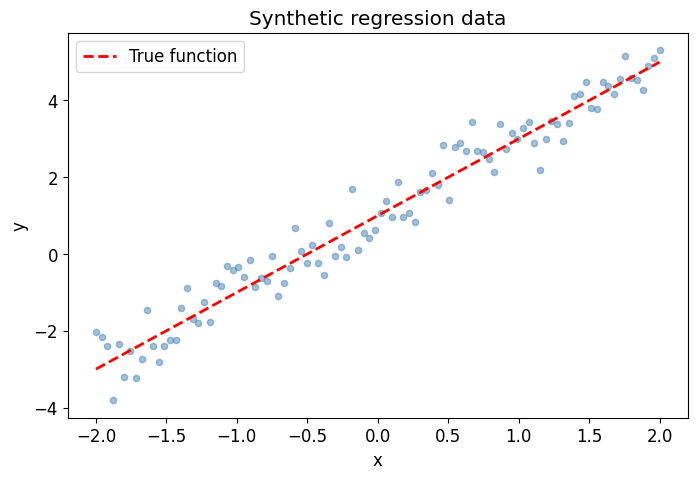

Generated 100 data points with w=2.0, b=1.0, sigma=0.5


In [10]:
# True parameters
w_true = 2.0
b_true = 1.0
sigma_true = 0.5

# Generate data
torch.manual_seed(42)
N = 100
x_data = torch.linspace(-2, 2, N)
y_data = w_true * x_data + b_true + sigma_true * torch.randn(N)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_data.numpy(), y_data.numpy(), alpha=0.5, s=20, color='steelblue')
plt.plot(x_data.numpy(), (w_true * x_data + b_true).numpy(), 'r--', linewidth=2, label='True function')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic regression data')
plt.legend()
plt.savefig(f'{FIGURES_DIR}regression_data.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Generated {N} data points with w={w_true}, b={b_true}, sigma={sigma_true}')

### 2.3 The probabilistic linear regression model

Now we define the model from the slides:

$$y \mid x \sim \mathcal{N}(wx + b, \; \sigma^2)$$

In this first version we **fix** $\sigma = 0.5$ (we assume we already know the noise level). Only $w$ and $b$ are learnable parameters.

> **Note:** Fixing $\sigma$ is a simplification. In practice we don't know the noise level. In **Section 5** you will be asked to turn $\sigma$ into a learnable parameter and discover its value from data.

Two things to note about Pyro models:
1. **Parameters vs. fixed tensors:** `pyro.param` registers a value in Pyro's optimizer; a plain `torch.tensor` is fixed and never updated.
2. **`obs=y`:** passing `y=None` at prediction time makes `pyro.sample` draw from the predictive distribution instead of conditioning on data.

In [11]:
def linear_regression_model(x, y=None):
    """
    Probabilistic linear regression model: y | x ~ N(w*x + b, sigma²)

    Parameters:
        x: input features (tensor of shape [N])
        y: observed targets (tensor of shape [N]), or None for prediction
    """
    # ── Learnable parameters (pyro.param) ─────────────────────────────────────
    # Docs: https://docs.pyro.ai/en/stable/primitives.html#pyro.primitives.param
    w = pyro.param('w', torch.tensor(0.0))   # slope — unconstrained ∈ ℝ
    b = pyro.param('b', torch.tensor(0.0))   # intercept — unconstrained ∈ ℝ

    # ── Fixed noise level (NOT a learnable parameter) ─────────────────────────
    # sigma is a plain tensor, not registered in the ParamStore.
    # Pyro will never update it — it is treated as a known hyperparameter.
    # In Section 5 you will change this line to make sigma learnable.
    sigma = torch.tensor(0.5)

    # ── Deterministic forward pass ─────────────────────────────────────────────
    mean = w * x + b

    # ── Observed random variable (pyro.plate + pyro.sample) ───────────────────
    # Docs: https://docs.pyro.ai/en/stable/primitives.html#pyro.primitives.plate
    with pyro.plate('data', len(x)):
        # obs=y  → conditioning (evaluates log p(y | mean, sigma))
        # obs=None → prior predictive (samples ŷ ~ N(mean, sigma))
        pyro.sample('obs', dist.Normal(mean, sigma), obs=y)

print('Linear regression model defined!')
print('Parameters to learn: w (slope), b (intercept)')
print('Fixed:               sigma = 0.5  ← will become learnable in Section 5')

Linear regression model defined!
Parameters to learn: w (slope), b (intercept)
Fixed:               sigma = 0.5  ← will become learnable in Section 5


> **Key point:** Notice how the model reads almost like the mathematical definition:
>
> $$y \mid x \sim \mathcal{N}(wx + b, \sigma^2)$$
>
> This is the power of probabilistic programming: the **model specification maps directly to code**.

---
## 3. Pyro Inference: Maximum Likelihood via SVI

Now we need to **learn** the parameters $w$, $b$, $\sigma$ from data.

Recall from the slides:
- **Maximum Likelihood Estimation (MLE):** find $\theta = \{w, b, \sigma\}$ that maximizes $\log p(\mathcal{D} \mid \theta) = \sum_i \log p(y_i \mid x_i, \theta)$.
- Equivalently, we **minimize the negative log-likelihood (NLL)** using gradient descent.

Pyro uses [**SVI — Stochastic Variational Inference**](https://docs.pyro.ai/en/stable/inference_algos.html#pyro.infer.SVI) as its general-purpose inference engine. SVI is designed for variational Bayes, but it degenerates to plain MLE when:
- there are **no latent variables** (only `pyro.param`, no `pyro.sample` without `obs=`)
- the **guide is empty**

This makes SVI a convenient unified interface for both MLE (today) and Bayesian inference (Notebook 2).

### 3.1 The guide (empty for MLE)

In Pyro's [SVI framework](https://docs.pyro.ai/en/stable/inference_algos.html), every model needs a paired **guide** function (also called the *variational posterior* or *approximate posterior* $q_\phi$).

The guide must mirror the structure of the model:
- For every `pyro.sample('z', prior)` in the model (a **latent** variable), the guide must have a matching `pyro.sample('z', q)` that approximates the posterior $p(z \mid \mathcal{D})$.
- `pyro.param` entries do **not** appear in the guide — they are handled automatically.

Since our MLE model has **no latent variables** (all `pyro.sample` calls use `obs=`), the guide is empty. In Notebook 2, when we turn $w$, $b$, $\sigma$ into latent variables with priors, we will write a real guide.

In [12]:
def empty_guide(x, y=None):
    """
    Empty guide for MLE.

    The guide must have the same signature as the model so that SVI can call
    both with the same arguments. Since there are no latent variables to
    approximate, the body is just 'pass'.

    In Notebook 2 this will be replaced by a guide that declares
    variational distributions q(w), q(b), q(sigma) for Bayesian inference.
    """
    pass

print('Guide defined (empty for MLE).')
print('On Notebook 2, we will replace this with a real guide for Bayesian inference.')

Guide defined (empty for MLE).
On Notebook 2, we will replace this with a real guide for Bayesian inference.


### 3.2 Setting up SVI

[`SVI`](https://docs.pyro.ai/en/stable/inference_algos.html#pyro.infer.SVI) needs four things:

| Argument | What we pass | Why |
|:---------|:-------------|:----|
| `model` | `linear_regression_model` | Defines the joint distribution $p(y, \theta \mid x)$ |
| `guide` | `empty_guide` | Approximate posterior — empty for MLE |
| `optim` | `Adam({'lr': 0.05})` | Pyro optimizer wrapping a PyTorch optimizer ([docs](https://docs.pyro.ai/en/stable/optimizers.html)) |
| `loss` | `Trace_ELBO()` | The objective to minimize |

**About `Trace_ELBO`:** In full variational inference, [`Trace_ELBO`](https://docs.pyro.ai/en/stable/inference_algos.html#pyro.infer.Trace_ELBO) minimizes the negative Evidence Lower BOund (ELBO). When the guide is empty and there are no latent variables, the ELBO reduces exactly to:

$$-\text{ELBO} = -\log p(\mathcal{D} \mid \theta) = \text{NLL}$$

So `Trace_ELBO` with an empty guide **is just MLE**, even though the name sounds Bayesian. This will change in Notebook 2.

In [13]:
# ── Clear the ParamStore ───────────────────────────────────────────────────────
# Pyro keeps all pyro.param values in a GLOBAL store that persists across cells.
# Always call pyro.clear_param_store() before a new experiment, otherwise
# previously optimized values will be used as starting points (or cause name clashes).
# Docs: https://docs.pyro.ai/en/stable/params.html
pyro.clear_param_store()

# ── Optimizer ──────────────────────────────────────────────────────────────────
# pyro.optim.Adam wraps torch.optim.Adam but integrates with Pyro's ParamStore.
# Docs: https://docs.pyro.ai/en/stable/optimizers.html
optimizer = Adam({'lr': 0.05})

# ── SVI object ────────────────────────────────────────────────────────────────
# SVI is the main inference class. It pairs model and guide, and exposes .step()
# which: (1) runs model + guide, (2) computes the loss, (3) does a gradient step.
# Docs: https://docs.pyro.ai/en/stable/inference_algos.html#pyro.infer.SVI
svi = SVI(
    model=linear_regression_model,  # p(y | x, w, b) with sigma fixed to 0.5
    guide=empty_guide,               # empty for MLE
    optim=optimizer,
    loss=Trace_ELBO()                # with empty guide → reduces to -log p(D|w,b)
)

print("SVI is ready. Parameters to optimize: w, b  (sigma is fixed to 0.5)")

SVI is ready. Parameters to optimize: w, b  (sigma is fixed to 0.5)


### 3.3 Training loop

Each call to [`svi.step(*args)`](https://docs.pyro.ai/en/stable/inference_algos.html#pyro.infer.SVI.step) does one full iteration:
1. Calls `model(*args)` and `guide(*args)` to build an execution trace.
2. Evaluates `Trace_ELBO` on that trace → computes the loss (a scalar).
3. Calls `.backward()` and updates all `pyro.param` values via the optimizer.
4. Returns the **loss value as a plain Python float** (detached from the computation graph).

The loop is identical to a PyTorch training loop — no special syntax needed.

In [14]:
num_steps = 1000
losses = []

for step in range(num_steps):
    # svi.step(): forward pass → loss → backward → param update. Returns a float.
    loss = svi.step(x_data, y_data)
    losses.append(loss)

    if (step + 1) % 200 == 0:
        w_est = pyro.param('w').item()
        b_est = pyro.param('b').item()
        print(f'Step {step+1:4d} | Loss: {loss:.2f} | w={w_est:.3f} | b={b_est:.3f}')

Step  200 | Loss: 70.72 | w=1.993 | b=1.030
Step  400 | Loss: 70.72 | w=1.993 | b=1.030
Step  600 | Loss: 70.72 | w=1.993 | b=1.030
Step  800 | Loss: 70.72 | w=1.993 | b=1.030
Step 1000 | Loss: 70.72 | w=1.993 | b=1.030


### 3.4 Visualizing the training loss

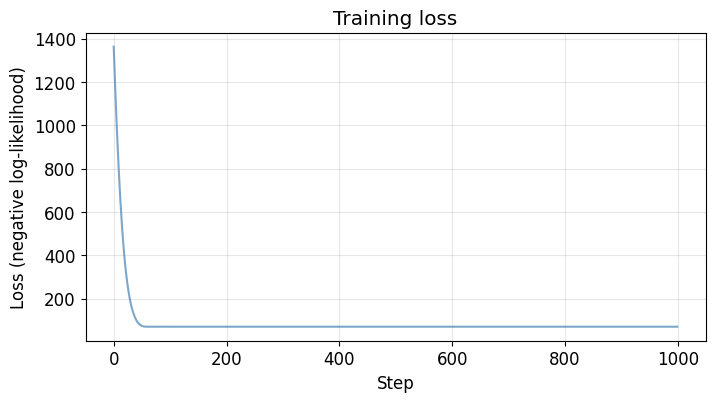

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue', alpha=0.7)
plt.xlabel('Step')
plt.ylabel('Loss (negative log-likelihood)')
plt.title('Training loss')
plt.grid(True, alpha=0.3)
plt.savefig(f'{FIGURES_DIR}training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Inspecting the learned parameters

Let's compare the learned $w$ and $b$ with the true values. Recall that $\sigma = 0.5$ was fixed — only $w$ and $b$ were optimized.

In [16]:
# Extract learned parameters from Pyro's ParamStore
w_learned = pyro.param('w').item()
b_learned = pyro.param('b').item()

# sigma was NOT registered as a pyro.param — it was fixed.
# We define it here as a plain Python float for use in later cells.
sigma_fixed = 0.5

print('Parameter comparison:')
print(f'  w:  true = {w_true:.3f},  learned = {w_learned:.3f}')
print(f'  b:  true = {b_true:.3f},  learned = {b_learned:.3f}')
print()
print(f'  sigma: fixed to {sigma_fixed} (not learned in this version)')
print()
print('In Section 5 we will let Pyro learn sigma too.')

Parameter comparison:
  w:  true = 2.000,  learned = 1.993
  b:  true = 1.000,  learned = 1.030

  sigma: fixed to 0.5 (not learned in this version)

In Section 5 we will let Pyro learn sigma too.


---
## 4. Predictions with Uncertainty

The whole point of probabilistic regression: we don't just predict a number, we predict a **distribution**.

$$y_{\text{new}} \mid x_{\text{new}} \sim \mathcal{N}(\hat{w} x_{\text{new}} + \hat{b},\; \sigma^2)$$

Since $\sigma = 0.5$ is fixed, the uncertainty bands have **constant width** everywhere. This is a property of the homoscedastic noise assumption. In Section 5, when you learn $\sigma$ from data, the value will be the same (because $\sigma_{\text{true}} = 0.5$) — but in general, learning it lets the model adapt to the actual noise in the data.

### 4.1 Point prediction vs. distribution (slide figure)

First, let's create the figure from the slides that shows the difference between a point prediction and a distributional prediction.

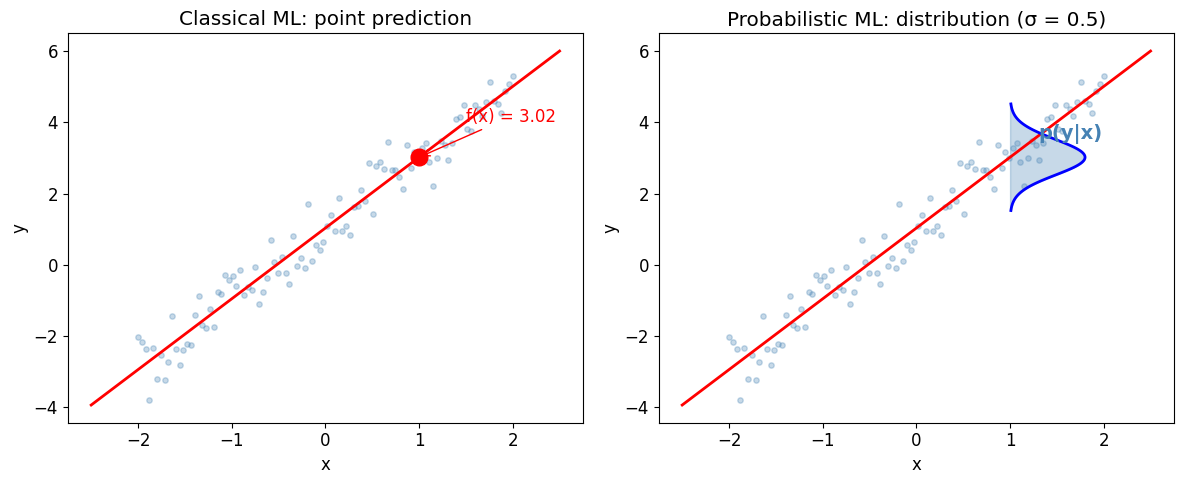

In [17]:
# Figure: point prediction vs distributional prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_example = 1.0
y_pred = w_learned * x_example + b_learned

# Left: point prediction
axes[0].scatter(x_data.numpy(), y_data.numpy(), alpha=0.3, s=15, color='steelblue')
x_line = torch.linspace(-2.5, 2.5, 100)
y_line = w_learned * x_line + b_learned
axes[0].plot(x_line.numpy(), y_line.numpy(), 'r-', linewidth=2)
axes[0].plot(x_example, y_pred, 'ro', markersize=12, zorder=5)
axes[0].set_title('Classical ML: point prediction')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].annotate(f'f(x) = {y_pred:.2f}', xy=(x_example, y_pred),
                 xytext=(x_example + 0.5, y_pred + 1),
                 fontsize=12, arrowprops=dict(arrowstyle='->', color='red'), color='red')

# Right: distributional prediction (using sigma_fixed = 0.5)
axes[1].scatter(x_data.numpy(), y_data.numpy(), alpha=0.3, s=15, color='steelblue')
axes[1].plot(x_line.numpy(), y_line.numpy(), 'r-', linewidth=2)

y_range = torch.linspace(y_pred - 3*sigma_fixed, y_pred + 3*sigma_fixed, 100)
gaussian_density = torch.exp(dist.Normal(y_pred, sigma_fixed).log_prob(y_range))
gaussian_density_scaled = gaussian_density / gaussian_density.max() * 0.8
axes[1].plot(x_example + gaussian_density_scaled.numpy(), y_range.numpy(), 'b-', linewidth=2)
axes[1].fill_betweenx(y_range.numpy(), x_example, x_example + gaussian_density_scaled.numpy(),
                      alpha=0.3, color='steelblue')
axes[1].set_title(f'Probabilistic ML: distribution (σ = {sigma_fixed})')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].annotate(f'p(y|x)', xy=(x_example + 0.3, y_pred + 0.5),
                 fontsize=14, color='steelblue', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}point_vs_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Regression fit with uncertainty bands

Now we plot the full regression line together with $\pm 1\sigma$ and $\pm 2\sigma$ bands.
Because $\sigma = 0.5$ is a fixed scalar (not a function of $x$), the bands have **constant width** everywhere — a hallmark of the homoscedastic noise assumption.

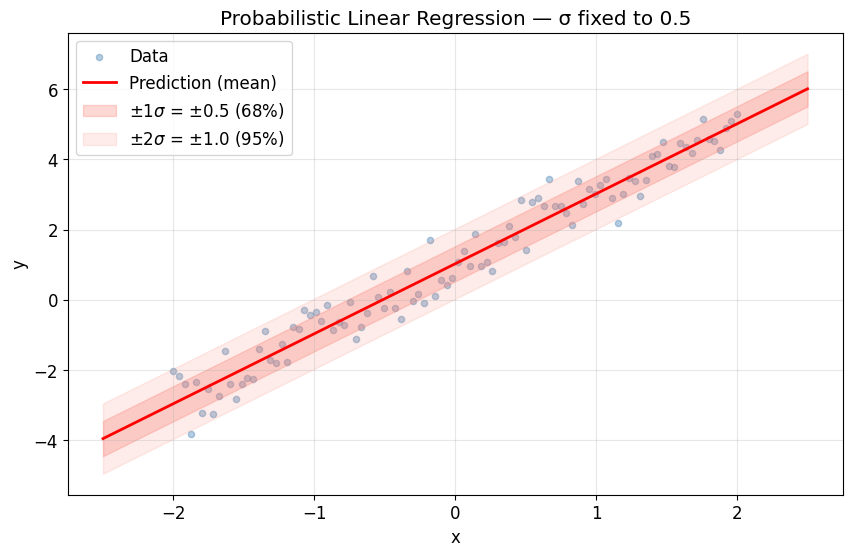

Fixed sigma = 0.5
~68% of data falls within ±0.5 of the predicted mean.
~95% falls within ±1.0.

These bands look reasonable because sigma_true = 0.5 matches our fixed value.


In [18]:
# Predictions over a grid
x_test = torch.linspace(-2.5, 2.5, 200)
y_mean = w_learned * x_test + b_learned

# Uncertainty bands — built from sigma_fixed = 0.5
y_upper_1 = y_mean + 1 * sigma_fixed
y_lower_1 = y_mean - 1 * sigma_fixed
y_upper_2 = y_mean + 2 * sigma_fixed
y_lower_2 = y_mean - 2 * sigma_fixed

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x_data.numpy(), y_data.numpy(), alpha=0.4, s=20, color='steelblue', label='Data')
plt.plot(x_test.numpy(), y_mean.numpy(), 'r-', linewidth=2, label='Prediction (mean)')
plt.fill_between(x_test.numpy(), y_lower_1.numpy(), y_upper_1.numpy(),
                 alpha=0.3, color='salmon', label=f'$\\pm 1\\sigma$ = ±{sigma_fixed} (68%)')
plt.fill_between(x_test.numpy(), y_lower_2.numpy(), y_upper_2.numpy(),
                 alpha=0.15, color='salmon', label=f'$\\pm 2\\sigma$ = ±{2*sigma_fixed} (95%)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Probabilistic Linear Regression — σ fixed to {sigma_fixed}')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.savefig(f'{FIGURES_DIR}linear_regression_with_bands.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fixed sigma = {sigma_fixed}')
print(f'~68% of data falls within ±{sigma_fixed} of the predicted mean.')
print(f'~95% falls within ±{2*sigma_fixed}.')
print()
print('These bands look reasonable because sigma_true = 0.5 matches our fixed value.')

> **Observation:** The uncertainty bands have **constant width** across all values of $x$. This is because the noise $\sigma = 0.5$ is a fixed scalar — it does not depend on $x$ (homoscedastic model).
>
> The bands look well-calibrated because we happened to fix $\sigma$ to its true value. But in a real problem we wouldn't know $\sigma_{\text{true}}$. That's the motivation for Section 5: let the model **learn** $\sigma$ from data.

### 4.3 Verifying our result: MSE connection

Let's verify the key insight from the slides: MLE with a Gaussian model gives the **same** $w$ and $b$ as minimizing MSE.

In [19]:
# Analytical OLS solution for comparison
X = torch.stack([x_data, torch.ones_like(x_data)], dim=1)  # design matrix [N, 2]
theta_ols = torch.linalg.lstsq(X, y_data).solution
w_ols, b_ols = theta_ols[0].item(), theta_ols[1].item()

# Analytical MLE sigma (what we WOULD learn if sigma were a parameter)
residuals = y_data - (w_ols * x_data + b_ols)
sigma_mle = torch.sqrt((residuals**2).mean()).item()

print('Comparison: Pyro MLE vs. Analytical OLS')
print(f'  w:  Pyro = {w_learned:.4f},  OLS = {w_ols:.4f}')
print(f'  b:  Pyro = {b_learned:.4f},  OLS = {b_ols:.4f}')
print()
print(f'  sigma:  fixed to {sigma_fixed} in this model,  MLE estimate = {sigma_mle:.4f}')
print()
print('w and b match — MLE with Gaussian noise = MSE (for the mean parameters).')
print(f'Note: the MLE estimate of sigma ({sigma_mle:.4f}) is very close to our fixed value ({sigma_fixed}).')
print('In Section 5 you will learn sigma from data and verify this directly.')

Comparison: Pyro MLE vs. Analytical OLS
  w:  Pyro = 1.9926,  OLS = 1.9926
  b:  Pyro = 1.0299,  OLS = 1.0299

  sigma:  fixed to 0.5 in this model,  MLE estimate = 0.4906

w and b match — MLE with Gaussian noise = MSE (for the mean parameters).
Note: the MLE estimate of sigma (0.4906) is very close to our fixed value (0.5).
In Section 5 you will learn sigma from data and verify this directly.


---
## Summary

In this notebook we have introduced the core Pyro concepts:

| Concept | Pyro primitive | What it does |
|:--------|:---------------|:-------------|
| Distribution | `dist.Normal(...)` | Defines a probability distribution |
| Random variable | `pyro.sample('name', dist, obs=...)` | Declares an observed or latent variable |
| Learnable parameter | `pyro.param('name', init, constraint=...)` | Declares a parameter to optimize |
| Independence | `pyro.plate('name', N)` | Declares N independent observations |
| Inference | `SVI(model, guide, optim, loss)` | Optimizes parameters by minimizing NLL |

We applied these to **probabilistic linear regression** and saw that:

- The model maps directly from math to Pyro code.
- MLE recovers the same $w, b$ as minimizing MSE.
- Fixing $\sigma$ is simple: just use a plain `torch.tensor`, not `pyro.param`.

**Next step:** In Section 5 below, you will make $\sigma$ learnable. Then in Notebook 2, we will replace the linear function with a neural network — the probabilistic framework stays exactly the same.

---
## 5. Exercise: Learning $\sigma$ from Data

So far we fixed $\sigma = 0.5$ because we happened to know the true noise level. In practice, **we never know $\sigma$** — it must be inferred from data along with $w$ and $b$.

### What you need to do

Complete the scaffold in **Section 5.1** below: modify `linear_regression_model_v2` so that $\sigma$ is a **learnable parameter** instead of a fixed tensor. Then run the training cell and the two result cells, and answer the questions below.

---

### Step-by-step hints

**Hint 1 — Which line to change.**
Find this line in the model:
```python
sigma = torch.tensor(0.5)
```
Replace it with a `pyro.param(...)` declaration.

**Hint 2 — Syntax of `pyro.param` with a constraint.**
```python
sigma = pyro.param(
    'sigma',                                              # unique name in the ParamStore
    torch.tensor(1.0),                                   # initial value (your starting guess)
    constraint=pyro.distributions.constraints.positive   # sigma must be > 0
)
```
The `constraint=positive` argument is critical: without it, the optimizer could push $\sigma$ to negative values, which would make `dist.Normal(mean, sigma)` crash. Pyro automatically reparameterizes to keep $\sigma > 0$.
→ Docs: [pyro.param](https://docs.pyro.ai/en/stable/primitives.html#pyro.primitives.param) · [constraints](https://docs.pyro.ai/en/stable/distributions.html#module-torch.distributions.constraints)

**Hint 3 — What else to update.**
After modifying the model, remember to:
1. Add `sigma` to the print statement inside the training loop so you can monitor it.
2. Extract `pyro.param('sigma').item()` after training and compare it to `sigma_true = 0.5`.
3. Rebuild the uncertainty bands using the **learned** `sigma` instead of `sigma_fixed`.

**Hint 4 — Don't forget `pyro.clear_param_store()`.**
Before re-running SVI, always call `pyro.clear_param_store()` to reset all parameters to their initial values. Otherwise Pyro will reuse the $w$ and $b$ values from the previous run.

---

### Questions to answer

1. What value does Pyro learn for $\sigma$? How close is it to $\sigma_{\text{true}} = 0.5$?
2. Do the uncertainty bands change compared to Section 4? Why or why not?
3. What would happen if you initialised $\sigma$ to a very wrong value, e.g., `torch.tensor(5.0)`? Try it.
4. What would happen if you forgot the `constraint=positive`? Try it and observe the error.

### 5.1 Modified model — your code here

Copy the model from Section 2.3 into the cell below and make the change described above.

In [20]:
def linear_regression_model_v2(x, y=None):
    """
    Modified model: w, b, AND sigma are all learnable parameters.
    """
    w = pyro.param('w', torch.tensor(0.0))
    b = pyro.param('b', torch.tensor(0.0))

    # TODO: replace the line below with a pyro.param declaration for sigma.
    # Remember to add the constraint=pyro.distributions.constraints.positive argument.
    sigma = torch.tensor(0.5)   # ← CHANGE THIS LINE

    mean = w * x + b
    with pyro.plate('data', len(x)):
        pyro.sample('obs', dist.Normal(mean, sigma), obs=y)


# --- Training ---
pyro.clear_param_store()

svi_v2 = SVI(
    model=linear_regression_model_v2,
    guide=empty_guide,
    optim=Adam({'lr': 0.05}),
    loss=Trace_ELBO()
)

losses_v2 = []
for step in range(1000):
    loss = svi_v2.step(x_data, y_data)
    losses_v2.append(loss)
    if (step + 1) % 200 == 0:
        w_est = pyro.param('w').item()
        b_est = pyro.param('b').item()
        # TODO: also print sigma here once it is a pyro.param
        print(f'Step {step+1:4d} | Loss: {loss:.2f} | w={w_est:.3f} | b={b_est:.3f}')

Step  200 | Loss: 70.72 | w=1.993 | b=1.030
Step  400 | Loss: 70.72 | w=1.993 | b=1.030
Step  600 | Loss: 70.72 | w=1.993 | b=1.030
Step  800 | Loss: 70.72 | w=1.993 | b=1.030
Step 1000 | Loss: 70.72 | w=1.993 | b=1.030


In [21]:
# --- Compare learned parameters with true values ---
w_v2     = pyro.param('w').item()
b_v2     = pyro.param('b').item()
# TODO: extract sigma_v2 = pyro.param('sigma').item() and add it to the comparison below

print('Results after learning sigma:')
print(f'  w:     true = {w_true:.3f},   learned = {w_v2:.3f}')
print(f'  b:     true = {b_true:.3f},   learned = {b_v2:.3f}')
# TODO: print sigma comparison here

Results after learning sigma:
  w:     true = 2.000,   learned = 1.993
  b:     true = 1.000,   learned = 1.030


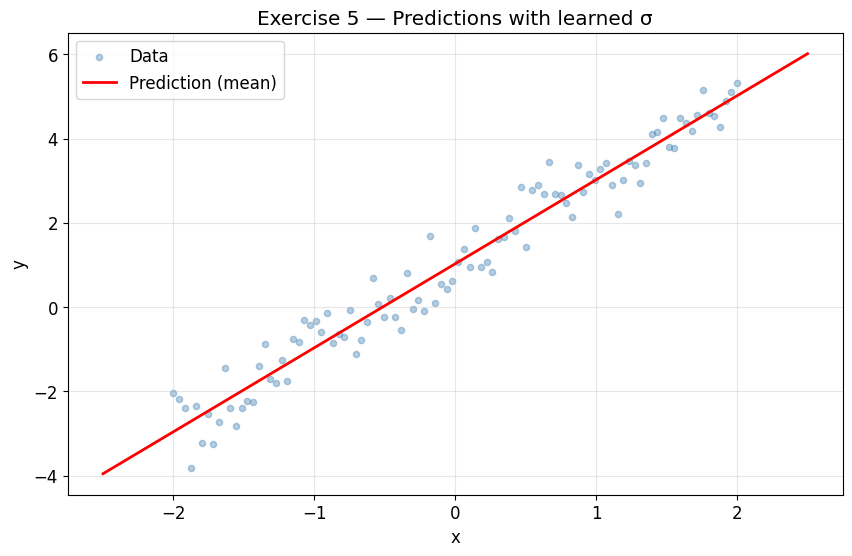

In [22]:
# --- Plot: compare uncertainty bands with fixed sigma vs. learned sigma ---
# TODO: once you have sigma_v2, add a second set of bands to this plot
#       and compare it visually with the bands from Section 4.

x_test = torch.linspace(-2.5, 2.5, 200)
y_mean_v2 = w_v2 * x_test + b_v2

plt.figure(figsize=(10, 6))
plt.scatter(x_data.numpy(), y_data.numpy(), alpha=0.4, s=20, color='steelblue', label='Data')
plt.plot(x_test.numpy(), y_mean_v2.numpy(), 'r-', linewidth=2, label='Prediction (mean)')

# TODO: add uncertainty bands using sigma_v2 (the learned value)
# Hint: copy the fill_between calls from Section 4 and replace sigma_fixed → sigma_v2

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exercise 5 — Predictions with learned σ')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()